# 03 · NYC shooting trends and fatality modelling (2006–2025)

This notebook answers three descriptive questions and tests a deliberately modest predictive benchmark:

1. How did recorded shooting incidents change over time?
2. How strong is the seasonal pattern?
3. How does victim fatality rate vary by location class?
4. Can incident context distinguish fatal from non-fatal victim outcomes in a future-period holdout?

Policy dates are useful context, but the analysis is observational and does **not** estimate policy effects.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"blue": "#2563EB", "red": "#DC2626", "slate": "#334155"}

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data" / "processed"
FIGURE_DIR = ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

shootings = pd.read_csv(DATA_DIR / "shootings_clean.csv", parse_dates=["OCCUR_DATETIME"])
victims = pd.read_csv(DATA_DIR / "shooting_victims_enriched.csv", parse_dates=["OCCUR_DATETIME"])
victims = victims.dropna(subset=["OCCUR_DATETIME", "IS_FATAL"]).copy()
victims["IS_FATAL"] = victims["IS_FATAL"].astype(int)

pd.Series(
    {
        "incident_rows": len(shootings),
        "victim_rows_with_incident_context": len(victims),
        "fatal_victim_share": victims["IS_FATAL"].mean(),
        "first_year": int(shootings["OCCUR_DATETIME"].dt.year.min()),
        "last_year": int(shootings["OCCUR_DATETIME"].dt.year.max()),
    },
    name="analysis_scope",
)

incident_rows                        23988.000000
victim_rows_with_incident_context    28746.000000
fatal_victim_share                       0.166319
first_year                            2006.000000
last_year                             2025.000000
Name: analysis_scope, dtype: float64

## Recorded incidents and fatal victims over time

In [2]:
annual_incidents = shootings.groupby(shootings["OCCUR_DATETIME"].dt.year).size()
annual_fatalities = victims.groupby(victims["OCCUR_DATETIME"].dt.year)["IS_FATAL"].sum()
annual = pd.concat(
    [annual_incidents.rename("incidents"), annual_fatalities.rename("fatal_victims")],
    axis=1,
)
annual.index.name = "year"
annual.loc[[2006, 2019, 2020, 2021, 2025]]

,incidents,fatal_victims
year,,
2006,1566,349
2019,777,154
2020,1532,292
2021,1562,325
2025,688,146


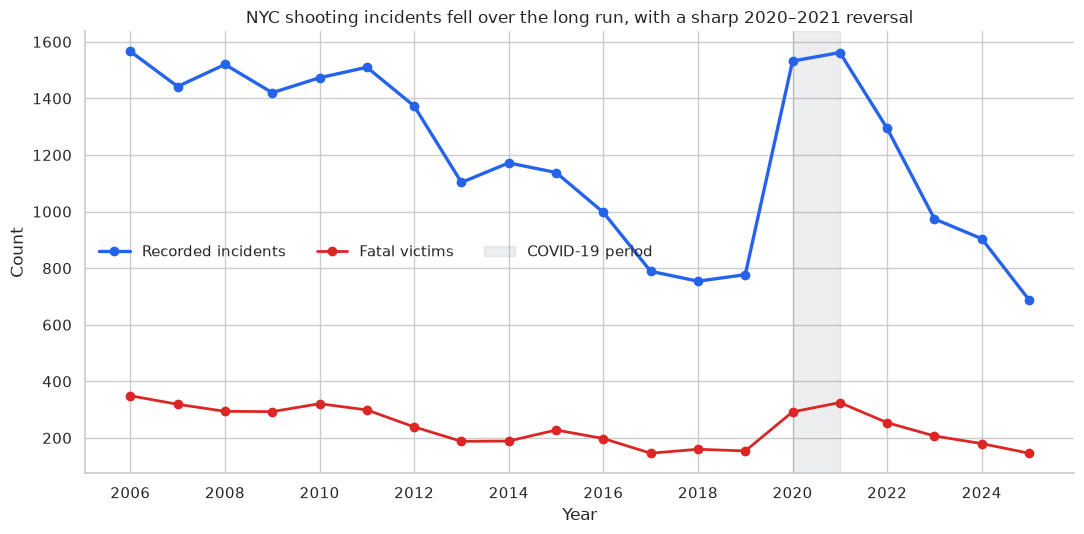

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(annual.index, annual["incidents"], marker="o", linewidth=2.4,
        color=COLORS["blue"], label="Recorded incidents")
ax.plot(annual.index, annual["fatal_victims"], marker="o", linewidth=2.0,
        color=COLORS["red"], label="Fatal victims")
ax.axvspan(2020, 2021, color=COLORS["slate"], alpha=0.09, label="COVID-19 period")
ax.set(title="NYC shooting incidents fell over the long run, with a sharp 2020–2021 reversal",
       xlabel="Year", ylabel="Count")
ax.set_xticks(range(2006, 2026, 2))
ax.legend(frameon=False, ncols=3)
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "annual_trend.png", dpi=180, bbox_inches="tight")
plt.show()

Recorded incidents declined from **1,566 in 2006 to 777 in 2019** (−50.4%), then nearly doubled to 1,532 in 2020. The series peaked at 1,562 in 2021 and declined to 688 in 2025, the lowest full-year count in this extract. These are descriptive breakpoints; attributing them to any single law or program would require a causal design and comparison group.

## Seasonality

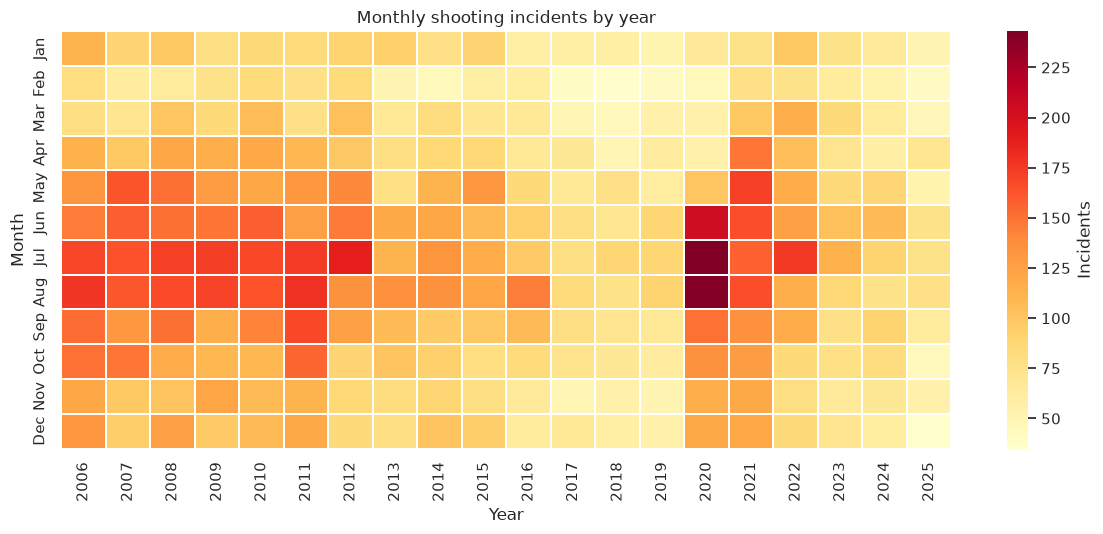

,average_incidents
Jul,138.9
Aug,135.0
Jun,124.8
Sep,112.4
May,109.8
Oct,99.7
Apr,89.2
Dec,88.7
Nov,86.2
Jan,77.9


In [4]:
seasonal = shootings.dropna(subset=["OCCUR_DATETIME"]).assign(
    year=lambda frame: frame["OCCUR_DATETIME"].dt.year,
    month=lambda frame: frame["OCCUR_DATETIME"].dt.month,
)
monthly = seasonal.pivot_table(index="month", columns="year", values="INCIDENT_KEY", aggfunc="count")
monthly = monthly.reindex(range(1, 13))
monthly.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(monthly, cmap="YlOrRd", linewidths=0.25, ax=ax, cbar_kws={"label": "Incidents"})
ax.set(title="Monthly shooting incidents by year", xlabel="Year", ylabel="Month")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "seasonality_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

monthly.mean(axis=1).sort_values(ascending=False).rename("average_incidents").round(1).to_frame()

The heatmap shows a persistent warm-season concentration, with July and August near the top across most years. This is a recurring association, not evidence that temperature itself causes shootings; weather, daylight, outdoor activity, holidays, and other time-varying factors may overlap.

## Location volume and victim fatality rate

In [5]:
location = (
    victims.query("LOC_CLASSFCTN_DESC != 'Unknown'")
    .groupby("LOC_CLASSFCTN_DESC")["IS_FATAL"]
    .agg(victims="size", fatalities="sum", fatality_rate="mean")
    .sort_values("victims", ascending=True)
)
location["fatality_rate_pct"] = 100 * location["fatality_rate"]
location[["victims", "fatalities", "fatality_rate_pct"]].round(1)

,victims,fatalities,fatality_rate_pct
LOC_CLASSFCTN_DESC,,,
TAXI/LIVERY,33,14,42.4
PARKING LOT,92,25,27.2
TRANSIT,107,18,16.8
OTHER,165,30,18.2
VEHICLE,324,201,62.0
PLAYGROUND,405,70,17.3
COMMERCIAL,1335,286,21.4
DWELLING,2289,783,34.2
HOUSING,5156,817,15.8


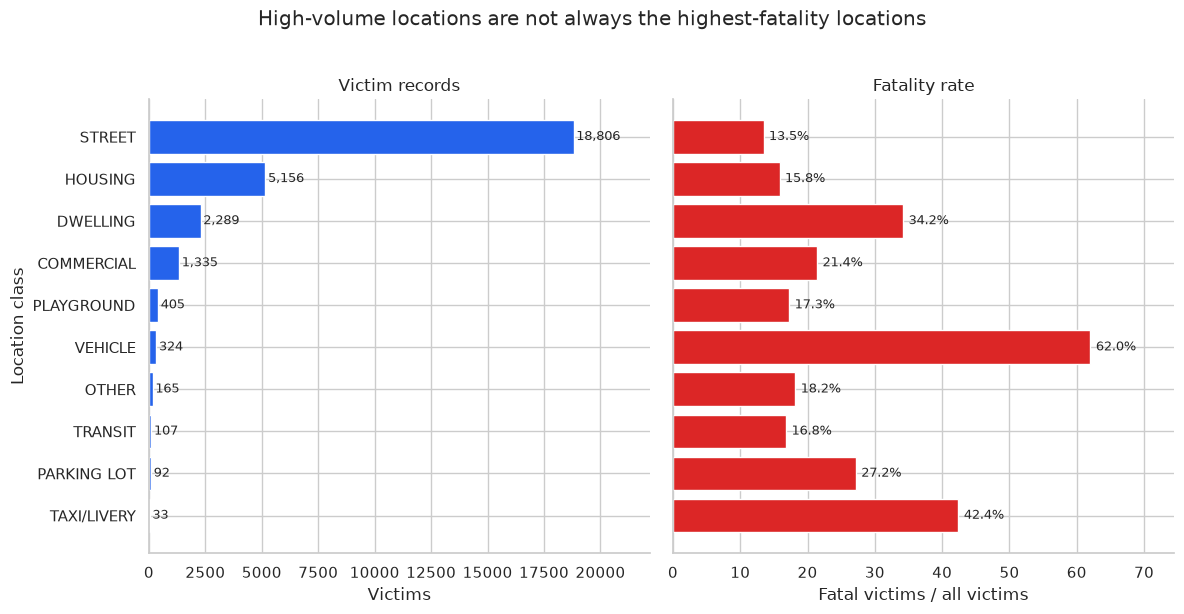

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].barh(location.index, location["victims"], color=COLORS["blue"])
axes[1].barh(location.index, location["fatality_rate_pct"], color=COLORS["red"])

for y, value in enumerate(location["victims"]):
    axes[0].text(value + 120, y, f"{value:,}", va="center", fontsize=9)
for y, value in enumerate(location["fatality_rate_pct"]):
    axes[1].text(value + 0.8, y, f"{value:.1f}%", va="center", fontsize=9)

axes[0].set(title="Victim records", xlabel="Victims", ylabel="Location class")
axes[1].set(title="Fatality rate", xlabel="Fatal victims / all victims")
axes[0].set_xlim(0, location["victims"].max() * 1.18)
axes[1].set_xlim(0, location["fatality_rate_pct"].max() * 1.2)
fig.suptitle("High-volume locations are not always the highest-fatality locations", y=1.02)
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "location_fatality.png", dpi=180, bbox_inches="tight")
plt.show()

Street incidents account for the most victim records, but their observed fatality rate is lower than rates for dwellings and vehicles. Small categories are unstable: vehicle and taxi/livery estimates come from far fewer victims than the street estimate, so the rates should not be read as equally precise or as causal effects of location.

## Fatality-classification benchmark

The model uses only incident context available in the record—time, borough, precinct, jurisdiction, and location descriptors. Victim race, sex, and age are intentionally excluded. A **2006–2021 training period** and **2022–2025 holdout** provide a harder and more realistic temporal test than a random split. The objective is to measure signal, not propose an operational public-safety tool.

In [7]:
model_data = victims.assign(
    OCCUR_YEAR=victims["OCCUR_DATETIME"].dt.year,
    OCCUR_MONTH=victims["OCCUR_DATETIME"].dt.month,
    OCCUR_HOUR=victims["OCCUR_DATETIME"].dt.hour,
)

categorical_features = ["BORO", "LOC_OF_OCCUR_DESC", "LOC_CLASSFCTN_DESC", "LOCATION_DESC"]
numeric_features = ["PRECINCT", "JURISDICTION_CODE", "OCCUR_MONTH", "OCCUR_HOUR"]
features = categorical_features + numeric_features

train = model_data[model_data["OCCUR_YEAR"] <= 2021]
test = model_data[model_data["OCCUR_YEAR"] >= 2022]
X_train, y_train = train[features], train["IS_FATAL"]
X_test, y_test = test[features], test["IS_FATAL"]

preprocess = ColumnTransformer(
    [
        (
            "categorical",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ]
)

models = {
    "Majority baseline": DummyClassifier(strategy="prior"),
    "Random forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
}

fitted = {}
for name, estimator in models.items():
    pipeline = Pipeline([("preprocess", preprocess), ("model", estimator)])
    pipeline.fit(X_train, y_train)
    fitted[name] = pipeline

pd.Series(
    {
        "training_rows_2006_2021": len(train),
        "holdout_rows_2022_2025": len(test),
        "holdout_fatality_prevalence": y_test.mean(),
    },
    name="split",
)

training_rows_2006_2021        24071.000000
holdout_rows_2022_2025          4675.000000
holdout_fatality_prevalence        0.168342
Name: split, dtype: float64

In [8]:
def evaluate(name, pipeline):
    prediction = pipeline.predict(X_test)
    probability = pipeline.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_test, prediction),
        "fatal_precision": precision_score(y_test, prediction, zero_division=0),
        "fatal_recall": recall_score(y_test, prediction, zero_division=0),
        "fatal_f1": f1_score(y_test, prediction, zero_division=0),
        "average_precision": average_precision_score(y_test, probability),
    }

metrics = pd.DataFrame(evaluate(name, model) for name, model in fitted.items()).set_index("model")
metrics.round(3)

,accuracy,balanced_accuracy,fatal_precision,fatal_recall,fatal_f1,average_precision
model,,,,,,
Majority baseline,0.832,0.500,0.000,0.000,0.000,0.168
Random forest,0.679,0.544,0.215,0.342,0.264,0.244


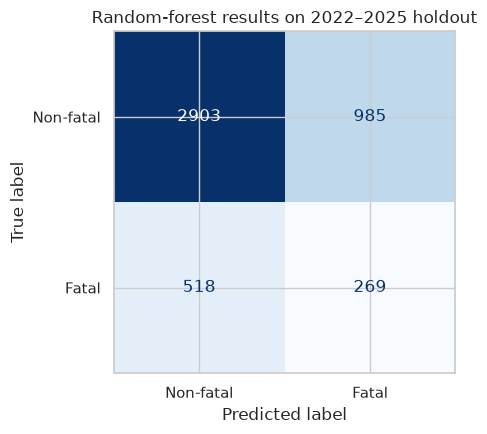

In [9]:
forest = fitted["Random forest"]
forest_predictions = forest.predict(X_test)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions,
    display_labels=["Non-fatal", "Fatal"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Random-forest results on 2022–2025 holdout")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

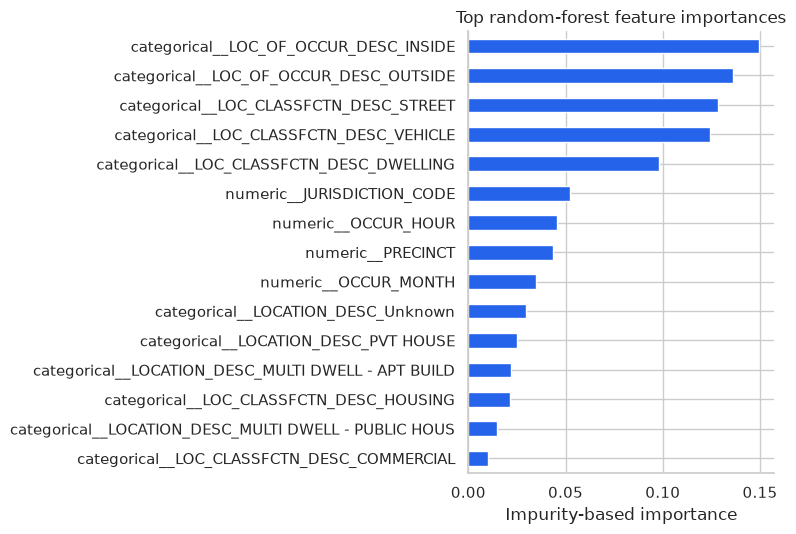

In [10]:
feature_names = forest.named_steps["preprocess"].get_feature_names_out()
importance = (
    pd.Series(forest.named_steps["model"].feature_importances_, index=feature_names)
    .sort_values()
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 5.5))
importance.plot.barh(ax=ax, color=COLORS["blue"])
ax.set(title="Top random-forest feature importances", xlabel="Impurity-based importance", ylabel="")
sns.despine()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

The model improves average precision over the holdout fatality prevalence, but its balanced accuracy and fatal-class recall remain modest. That is the useful result: location and time carry some signal, but not enough to support high-stakes use. Accuracy is especially misleading because roughly five in six holdout records are non-fatal.

### Limitations

- This is reported administrative data, not a complete measure of firearm violence or victimization risk.
- Counts are not population-adjusted, and demographic fields must not be interpreted as per-capita rates.
- Policy and pandemic annotations are contextual; no causal effect is estimated.
- Rare location classes produce unstable fatality-rate estimates.
- The classifier is an educational benchmark. It lacks clinical, situational, and response-time variables and is not suitable for deployment.

### Next steps

A stronger follow-up would add Census population denominators for borough-level rates, quantify uncertainty around fatality rates, and use an interrupted time-series or matched comparison design for a specific policy question.